# TTFS spike compression with exact gradient (Comsa et al.) + communication channel

This notebook replaces the previous version (snnTorch simulation discretized over T time
steps with a surrogate gradient), which suffered from a systematic bottleneck collapse:
the decompressor learned to ignore each example's content and always reconstruct an
image close to the dataset average, regardless of the input example.

**Diagnosis established before this notebook**: this was not a channel problem (the same
collapse appeared even with zero channel noise), nor a network capacity problem, but a
problem with the gradient itself. The snnTorch simulator discretizes time into T steps and
approximates the gradient of a binary spike decision with a *surrogate gradient* (straight-through
estimator) -- a noisy, biased approximation that must also pass through several
non-differentiable thresholds. The shortcut "ignore z and output a generic image" is then
much easier for the optimizer to learn than the real coding.

**The solution adopted here** faithfully reproduces the approach of:

> Comsa et al., *"Spiking Autoencoders With Temporal Coding"*, Frontiers in Neuroscience, 2021.
> Source code: [github.com/google/ihmehimmeli, branch `autoencoder`](https://github.com/google/ihmehimmeli/tree/autoencoder)

Instead of discretizing time, each neuron has **a single spike time, computed analytically
and exactly** (no approximation) via the Lambert W function, for a postsynaptic response
shaped as an alpha function $f(s) = s \cdot e^{-Ks}$. The gradient of this spike time with
respect to the weights and input times is also **exact** (closed form, obtained by implicit
differentiation of the threshold equation), rather than approximated. It is this gradient
precision -- not an architecture or initialization choice -- that turns out to be the real
missing ingredient: see the Diagnostics section below, where we find exactly the same
metrics as in the previous version (inter-example variance of x_hat, residual correlation
after removing the mean image) for an objective comparison.

The pipeline stays: **compressor** (fully-connected SNN, D_in -> K) -> **communication
channel** (Gaussian jitter on the bottleneck's spike times) -> **decompressor**
(K -> D_in) -> MSE loss on the reconstructed spike times vs. the input times.

The exact-gradient neuron implementation is in `alpha_ttfs.py` (keep it in the same folder
as this notebook); it was verified by comparison against a numerical gradient (finite
differences) before being used here.

In [1]:
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

from alpha_ttfs import AlphaTTFSLayer


np.random.seed(0)
print("OK")

OK


In [2]:
%matplotlib inline

## 1. Data and temporal coding (TTFS)

We reuse the small 8x8 digits dataset (64 pixels, values 0..16) from scikit-learn, as in
the previous version -- the pipeline transposes directly to a full 28x28 MNIST
(784 pixels) by just changing `D_in`, at the cost of a longer training time.

Each pixel becomes a single spike time: bright pixel (16) -> very early spike
(t=0), black pixel (0) -> late spike (t=16). This is "time-to-first-spike" (TTFS) coding,
strictly the same as in the paper.

In [3]:
digits = load_digits()
X = digits.data  # (n, 64), values 0..16
n = X.shape[0]
idx = np.random.permutation(n)
n_train = int(0.8 * n)
Xtr = torch.tensor(X[idx[:n_train]], dtype=torch.float32)
Xte = torch.tensor(X[idx[n_train:]], dtype=torch.float32)

D_IN = 64
T_MAX = 16.0

def pixels_to_times(pixels):
    # bright pixel -> small time (early spike), black pixel -> large time (late spike)
    return (16.0 - pixels).clamp(0, T_MAX)

print("train/test:", Xtr.shape, Xte.shape)

train/test: torch.Size([1437, 64]) torch.Size([360, 64])


## 2. Model: compressor -- channel -- decompressor

Each `AlphaTTFSLayer` is a fully-connected layer of exact-gradient neurons, with its own
learned **synchronization pulses** (Comsa et al.): extra virtual inputs, at learned times,
that give each neuron a reliable, content-independent temporal reference -- this is what
helps it learn WHEN to respond, while the "real" weights learn HOW to modulate this
reference time based on the input.

The **communication channel** (our simplified "timing channel") adds Gaussian noise
directly to the compressed bottleneck's spike times, before transmitting them to the
decompressor -- exactly the point you had raised: we want a channel INSIDE the training
loop (the decompressor sees already-noisy times), not a channel ignored and added back
afterward.

In [4]:
K_BOTTLENECK = 8  # bottleneck size (compare to D_IN=64 pixels: x8 compression)

# Hyperparameters adapted from the official repo's hyperparameter search
# (ihmehimmeli/hyperparameters, row noise_factor_ae=0.0 latency_ae=1 n_hidden=8)
K_DECAY = 0.113
THRESHOLD = 1.40
N_PULSES = 10
LR_WEIGHTS = 0.0025
LR_PULSES = 0.009
CLIP_DERIV = 600.0
NONPULSE_MULT = -8.9
PULSE_MULT = 6.4
PENALTY_NO_SPIKE = 65.0
BATCH_SIZE = 18
LATENCY_AE = 1.0   # expected time offset between the network's input and output
SIGMA_JITTER = 1 # channel noise standard deviation (in time units)

compressor = AlphaTTFSLayer(D_IN, K_BOTTLENECK, n_pulses=N_PULSES, threshold=THRESHOLD,
                             decay_rate=K_DECAY, pulse_range=(0, T_MAX),
                             nonpulse_weight_mean_multiplier=NONPULSE_MULT,
                             pulse_weight_mean_multiplier=PULSE_MULT,
                             clip_derivative=CLIP_DERIV)
decompressor = AlphaTTFSLayer(K_BOTTLENECK, D_IN, n_pulses=N_PULSES, threshold=THRESHOLD,
                               decay_rate=K_DECAY, pulse_range=(0, T_MAX),
                               nonpulse_weight_mean_multiplier=NONPULSE_MULT,
                               pulse_weight_mean_multiplier=PULSE_MULT,
                               clip_derivative=CLIP_DERIV)

"""def channel(z_time, sigma):
    # channel = additive Gaussian noise on the bottleneck's spike time (simplified timing channel)
    if sigma > 0:
        z_time = z_time + torch.randn_like(z_time) * sigma
    return z_time.clamp(min=0.0)"""

def channel(z_time, delay):
    # channel = fixed (deterministic) delay, the same offset for all neurons and all examples
    return (z_time + delay).clamp(min=0.0)

def forward_pass(pixels, sigma):
    x_time = pixels_to_times(pixels)
    z_time, z_has = compressor(x_time)
    z_time_noisy = channel(z_time, sigma)
    xhat_time, xhat_has = decompressor(z_time_noisy)
    return x_time, z_time, xhat_time, z_has, xhat_has

n_params = sum(p.numel() for p in list(compressor.parameters()) + list(decompressor.parameters()))
print(f"compression: {D_IN} -> {K_BOTTLENECK} (ratio x{D_IN/K_BOTTLENECK:.1f}), {n_params} parameters in total")

compression: 64 -> 8 (ratio x8.0), 1764 parameters in total


## 3. Training

The main loss is an MSE between the output time (aligned by `LATENCY_AE`, the time offset
structurally expected between the input instant and the output instant after propagation
through the network) and the true input time -- exactly the `ComputeLossWithPenalty` loss
from the official repo.

We add an auxiliary `no_spike_penalty` term: when a neuron never spikes for a given
example, its normal gradient is zero (there is literally no spike whose time we could
differentiate) -- this term artificially injects a gradient that pushes its weights to
increase until it starts spiking, exactly the paper's trick
("small positive-valued penalty ... to encourage spiking").

epoch   0 | train 111.3628 | test 103.4478 | frac spike z 0.000 xhat 1.000


epoch  10 | train 19.1136 | test 19.1744 | frac spike z 1.000 xhat 1.000


epoch  20 | train 17.7859 | test 17.9293 | frac spike z 1.000 xhat 1.000


epoch  30 | train 16.3588 | test 16.3372 | frac spike z 1.000 xhat 1.000


epoch  40 | train 15.1004 | test 15.0673 | frac spike z 1.000 xhat 1.000


...

epoch 110 | train 8.9960 | test 9.1035 | frac spike z 1.000 xhat 1.000


epoch 120 | train 8.8677 | test 9.0133 | frac spike z 1.000 xhat 1.000


epoch 130 | train 8.8427 | test 8.9269 | frac spike z 1.000 xhat 1.000


epoch 140 | train 8.6489 | test 8.7095 | frac spike z 1.000 xhat 1.000


epoch 149 | train 8.5749 | test 8.6083 | frac spike z 1.000 xhat 1.000
training time: 25.6s


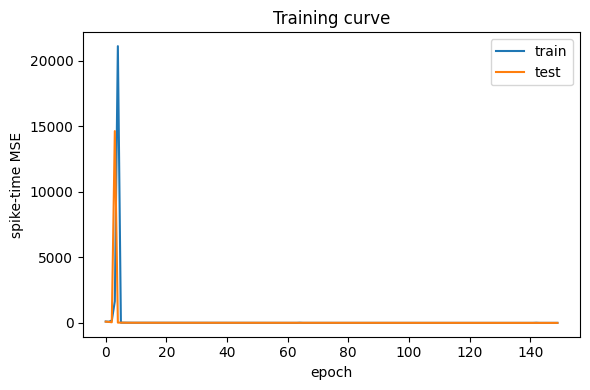

In [5]:
weight_params = [compressor.weight, decompressor.weight]
pulse_params = [compressor.pulse_times, decompressor.pulse_times]
opt = torch.optim.Adam([
    {'params': weight_params, 'lr': LR_WEIGHTS},
    {'params': pulse_params, 'lr': LR_PULSES},
])

n_epochs = 150
n_train_ = Xtr.shape[0]
train_losses, test_losses = [], []

t0 = time.time()
for epoch in range(n_epochs):
    perm = torch.randperm(n_train_)
    ep_loss, nb = 0.0, 0
    for start in range(0, n_train_, BATCH_SIZE):
        b = perm[start:start + BATCH_SIZE]
        pixels = Xtr[b]
        opt.zero_grad()
        x_time, z_time, xhat_time, z_has, xhat_has = forward_pass(pixels, SIGMA_JITTER)
        aligned = xhat_time - LATENCY_AE
        recon = torch.mean((aligned - x_time) ** 2)
        no_spike_aux = PENALTY_NO_SPIKE * (compressor.no_spike_penalty(z_has) +
                                            decompressor.no_spike_penalty(xhat_has))
        loss = recon + no_spike_aux
        loss.backward()
        torch.nn.utils.clip_grad_norm_(weight_params + pulse_params, 50.0)
        opt.step()
        ep_loss += recon.item()
        nb += 1
    train_losses.append(ep_loss / nb)

    with torch.no_grad():
        x_time_te, z_time_te, xhat_time_te, z_has_te, xhat_has_te = forward_pass(Xte, SIGMA_JITTER)
        test_loss = torch.mean(((xhat_time_te - LATENCY_AE) - x_time_te) ** 2).item()
    test_losses.append(test_loss)

    if epoch % 10 == 0 or epoch == n_epochs - 1:
        print(f"epoch {epoch:3d} | train {train_losses[-1]:.4f} | test {test_losses[-1]:.4f} "
              f"| frac spike z {z_has_te.float().mean().item():.3f} xhat {xhat_has_te.float().mean().item():.3f}")

print(f"training time: {time.time()-t0:.1f}s")

plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="train")
plt.plot(test_losses, label="test")
plt.xlabel("epoch")
plt.ylabel("spike-time MSE")
plt.title("Training curve")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Diagnostics -- is the bottleneck actually being used?

**Never trust the loss curve alone.** In the previous version
(snnTorch/surrogate gradient), the loss decreased quite convincingly even though
the decompressor had completely stopped using each example's specific content. The two
diagnostics below are the ones that had revealed the problem, and now let us objectively
verify that it is fixed:

- **Inter-example variance of x_hat vs x**: if the decompressor always reconstructs
  roughly the same image, this variance collapses toward 0 independent of x. A ratio
  close to 1 indicates a reconstruction that varies as much as the real images.
- **Residual correlation**: we first remove the dataset's mean image from x and x_hat,
  then correlate what remains. If x_hat merely reproduces the mean image, this
  residual correlation is zero (close to 0), even if the raw correlation seemed
  reasonable.
- **Model MSE vs. a degenerate baseline's MSE** ("always predict the mean image"):
  if the model does no better than this trivial baseline, it has learned nothing
  useful about the content.

In [6]:
with torch.no_grad():
    x_time, z_time, xhat_time, z_has, xhat_has = forward_pass(Xte, SIGMA_JITTER)
    xhat_aligned = xhat_time - LATENCY_AE

var_x = x_time.var(dim=0).mean().item()
var_xhat = xhat_aligned.var(dim=0).mean().item()
print(f"inter-example variance -- x: {var_x:.3f}  x_hat: {var_xhat:.3f}  ratio: {var_xhat/var_x:.3f}  (1.0 = ideal, 0.0 = collapsed)")

mean_x_img = x_time.mean(dim=0, keepdim=True)
resid_x = x_time - mean_x_img
resid_xhat = xhat_aligned - xhat_aligned.mean(dim=0, keepdim=True)
num = (resid_x * resid_xhat).sum(dim=1)
den = resid_x.norm(dim=1) * resid_xhat.norm(dim=1) + 1e-8
resid_corr = (num / den).mean().item()
print(f"residual correlation (after removing the mean image): {resid_corr:.3f}  (0.0 = collapsed, close to 1.0 = ideal)")

baseline_mse = torch.mean((x_time - mean_x_img) ** 2).item()
model_mse = torch.mean((x_time - xhat_aligned) ** 2).item()
print(f"baseline MSE (always predict the mean image): {baseline_mse:.3f}")
print(f"model MSE (real x_hat):                        {model_mse:.3f}  "
      f"({'BETTER' if model_mse < baseline_mse else 'WORSE'} than the baseline)")
print(f"fraction of neurons that spike at least once -- bottleneck z: {z_has.float().mean().item():.3f}, "
      f"output x_hat: {xhat_has.float().mean().item():.3f}")

inter-example variance -- x: 18.954  x_hat: 10.299  ratio: 0.543  (1.0 = ideal, 0.0 = collapsed)
residual correlation (after removing the mean image): 0.734  (0.0 = collapsed, close to 1.0 = ideal)
baseline MSE (always predict the mean image): 18.902
model MSE (real x_hat):                        8.608  (BETTER than the baseline)
fraction of neurons that spike at least once -- bottleneck z: 1.000, output x_hat: 1.000


z_time for the first 6 test-set examples (8 values = 8 bottleneck neurons):

tensor([[ 3.38, 12.38, 13.59, 10.41,  9.06,  1.16,  0.97,  0.60],
        [ 2.41,  2.60,  9.57,  1.91,  4.21, 13.56,  4.12, 11.38],
        [10.29, 10.56,  8.99,  0.50,  1.30,  0.78,  4.98,  4.72],
        [ 7.91, 12.26,  9.04, 10.86,  3.70,  0.77,  2.81,  5.75],
        [ 1.29, 14.82, 11.13,  0.23, 11.01, 14.08,  5.55, 10.02],
        [10.27,  3.43,  2.20, 13.84,  1.26,  9.07, 14.89, 11.79]])

did it spike, for each (True = spiked):
tensor([[True, True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True, True]])


,example,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7
0,0,3.38,12.38,13.59,10.41,9.06,1.16,0.97,0.60
1,1,2.41,2.60,9.57,1.91,4.21,13.56,4.12,11.38
2,2,10.29,10.56,8.99,0.50,1.30,0.78,4.98,4.72
3,3,7.91,12.26,9.04,10.86,3.70,0.77,2.81,5.75
4,4,1.29,14.82,11.13,0.23,11.01,14.08,5.55,10.02
5,5,10.27,3.43,2.20,13.84,1.26,9.07,14.89,11.79
6,6,11.51,5.25,2.54,0.32,11.19,3.88,3.58,11.89
7,7,0.69,6.63,10.58,11.94,4.39,0.54,9.64,11.18
8,8,3.03,3.33,7.20,14.03,3.94,10.67,4.60,5.01
9,9,11.47,0.57,1.04,11.71,8.40,11.10,10.34,13.75


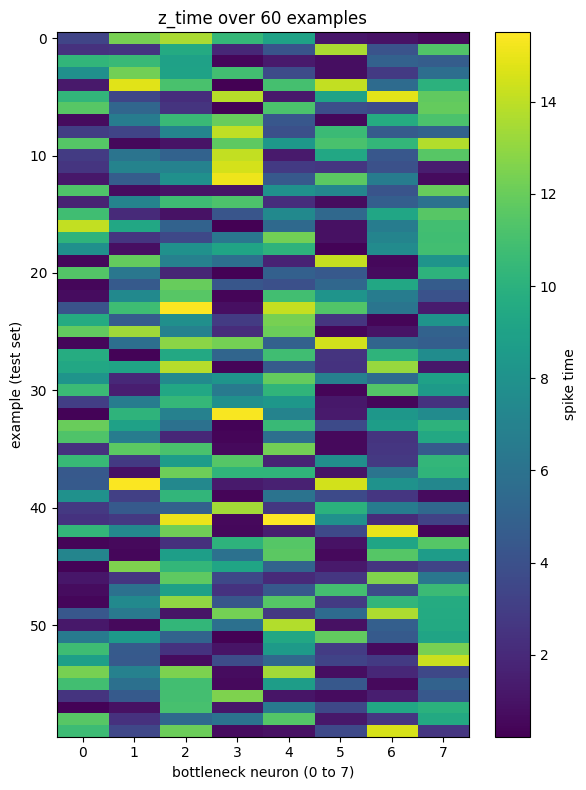

In [7]:
torch.set_printoptions(precision=2, sci_mode=False)

n_show = 6
print("z_time for the first", n_show, "test-set examples (8 values = 8 bottleneck neurons):\n")
print(z_time[:n_show])

print("\ndid it spike, for each (True = spiked):")
print(z_has[:n_show])

# "concrete" view as a table: one row per example, one column per bottleneck neuron
import pandas as pd
df_z = pd.DataFrame(z_time[:20].numpy(), columns=[f"z_{k}" for k in range(z_time.shape[1])])
df_z.insert(0, "example", range(20))
display(df_z.round(2))

# heatmap: structure of z across many examples at once
plt.figure(figsize=(6, 8))
plt.imshow(z_time[:60].numpy(), aspect="auto", cmap="viridis")
plt.colorbar(label="spike time")
plt.xlabel("bottleneck neuron (0 to 7)")
plt.ylabel("example (test set)")
plt.title("z_time over 60 examples")
plt.tight_layout()
plt.show()

## 5. Visual image reconstruction

<Figure size 640x480 with 0 Axes>

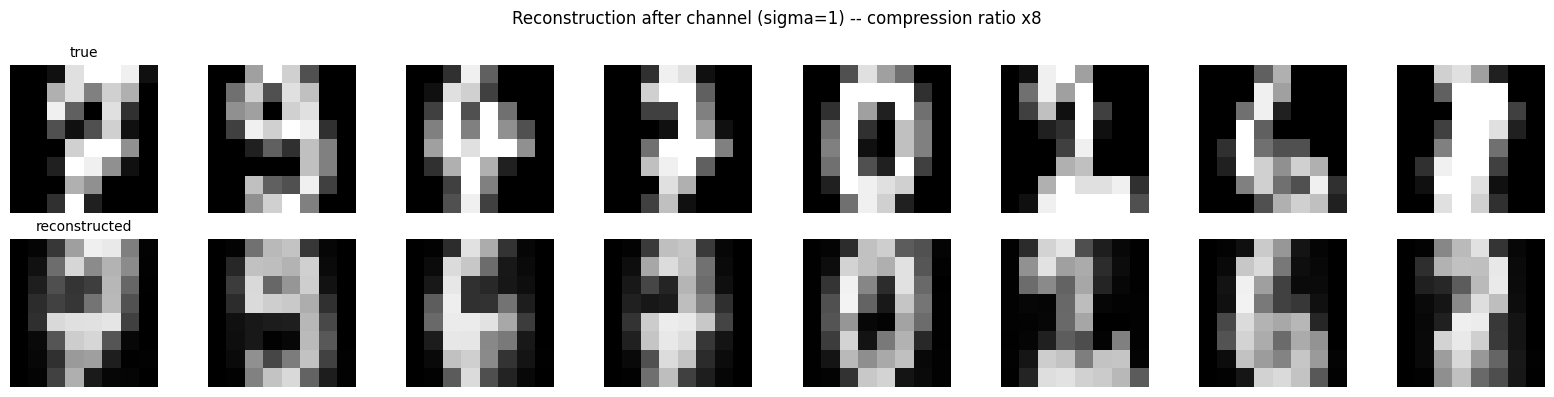

In [8]:
n_show = 8
plt.figure()
fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 4))
for i in range(n_show):
    true_img = x_time[i].clamp(0, T_MAX).view(8, 8).numpy()
    hat_img = xhat_aligned[i].clamp(0, T_MAX).view(8, 8).numpy()
    axes[0, i].imshow(16 - true_img, cmap="gray", vmin=0, vmax=16)
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_ylabel("true")
        axes[0, i].set_title("true", fontsize=10)
    axes[1, i].imshow(16 - hat_img, cmap="gray", vmin=0, vmax=16)
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("reconstructed", fontsize=10)
plt.suptitle(f"Reconstruction after channel (sigma={SIGMA_JITTER}) -- compression ratio x{D_IN/K_BOTTLENECK:.0f}")
plt.tight_layout()
plt.show()

## 6. Examples of reconstructed spikes (spike times, not a binary raster)

With a neuron having a single exact spike per example, the natural "raster" is no longer a
binary matrix (neuron x time step) like in the discretized version, but a simple
scatter of points (neuron, spike time) -- one point per neuron. Here we show, for a given
example, the true vs. reconstructed spike times for the input pixels, and the
compressed bottleneck's spike times (before/after channel).

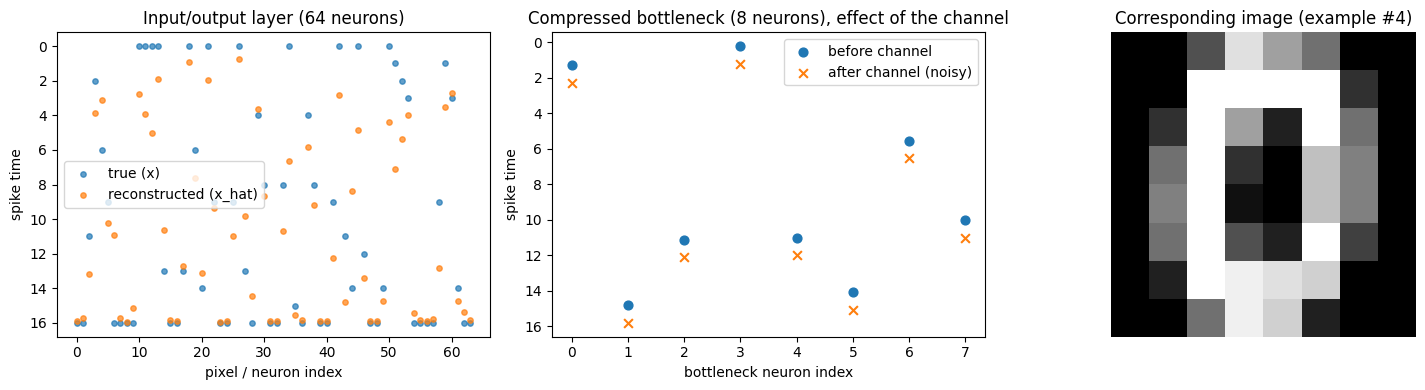

In [9]:
example_idx = 4  # the "0" from the test batch shown above

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(range(D_IN), x_time[example_idx].numpy(), s=15, label="true (x)", alpha=0.7)
axes[0].scatter(range(D_IN), xhat_aligned[example_idx].numpy(), s=15, label="reconstructed (x_hat)", alpha=0.7)
axes[0].set_xlabel("pixel / neuron index")
axes[0].set_ylabel("spike time")
axes[0].set_title("Input/output layer (64 neurons)")
axes[0].legend()
axes[0].invert_yaxis()

with torch.no_grad():
    z_time_ex, _ = compressor(pixels_to_times(Xte[example_idx:example_idx+1]))
    z_time_noisy_ex = channel(z_time_ex, SIGMA_JITTER)
axes[1].scatter(range(K_BOTTLENECK), z_time_ex[0].numpy(), s=40, label="before channel", marker="o")
axes[1].scatter(range(K_BOTTLENECK), z_time_noisy_ex[0].numpy(), s=40, label="after channel (noisy)", marker="x")
axes[1].set_xlabel("bottleneck neuron index")
axes[1].set_ylabel("spike time")
axes[1].set_title(f"Compressed bottleneck ({K_BOTTLENECK} neurons), effect of the channel")
axes[1].legend()
axes[1].invert_yaxis()

axes[2].imshow(16 - x_time[example_idx].view(8, 8).numpy(), cmap="gray", vmin=0, vmax=16)
axes[2].set_title(f"Corresponding image (example #{example_idx})")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 7. Robustness to channel noise

We reuse the already-trained model (with `SIGMA_JITTER=0.5` during training) and vary the
channel noise **at test time only**, to see how robust the learned code is -- this is the
real "joint source-channel coding" question: has the compressor learned a code that
degrades gracefully with noise, rather than collapsing abruptly?

channel sigma = 0.00  ->  test MSE = 9.288
channel sigma = 0.25  ->  test MSE = 8.973
channel sigma = 0.50  ->  test MSE = 8.779
channel sigma = 1.00  ->  test MSE = 8.608
channel sigma = 2.00  ->  test MSE = 9.549
channel sigma = 4.00  ->  test MSE = 14.066


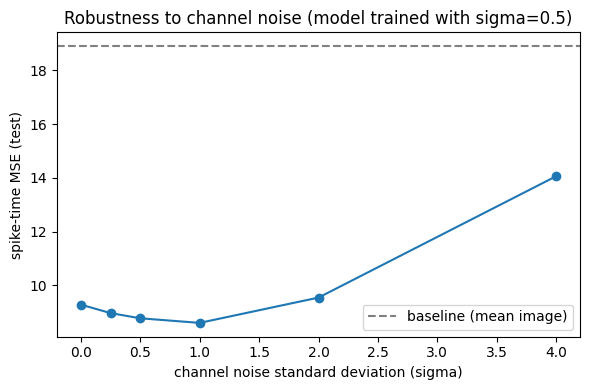

In [10]:
sigmas_test = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0]
mses = []
with torch.no_grad():
    for s in sigmas_test:
        x_time_s, _, xhat_time_s, _, _ = forward_pass(Xte, s)
        mse_s = torch.mean(((xhat_time_s - LATENCY_AE) - x_time_s) ** 2).item()
        mses.append(mse_s)
        print(f"channel sigma = {s:.2f}  ->  test MSE = {mse_s:.3f}")

plt.figure(figsize=(6, 4))
plt.plot(sigmas_test, mses, marker="o")
plt.axhline(baseline_mse, color="gray", linestyle="--", label="baseline (mean image)")
plt.xlabel("channel noise standard deviation (sigma)")
plt.ylabel("spike-time MSE (test)")
plt.title("Robustness to channel noise (model trained with sigma=0.5)")
plt.legend()
plt.tight_layout()
plt.show()

channel sigma = 0.00  ->  test MSE = 9.288
channel sigma = 0.25  ->  test MSE = 8.973
channel sigma = 0.50  ->  test MSE = 8.779
channel sigma = 1.00  ->  test MSE = 8.608
channel sigma = 2.00  ->  test MSE = 9.549
channel sigma = 4.00  ->  test MSE = 14.066


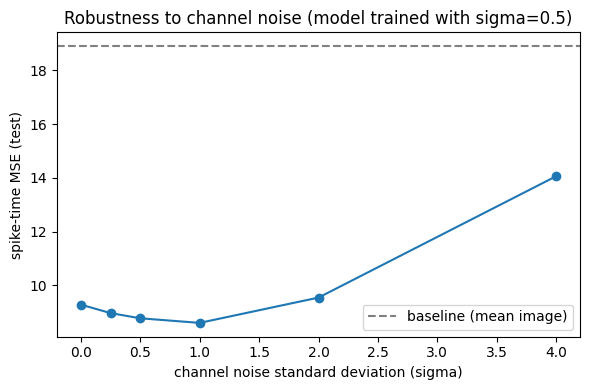

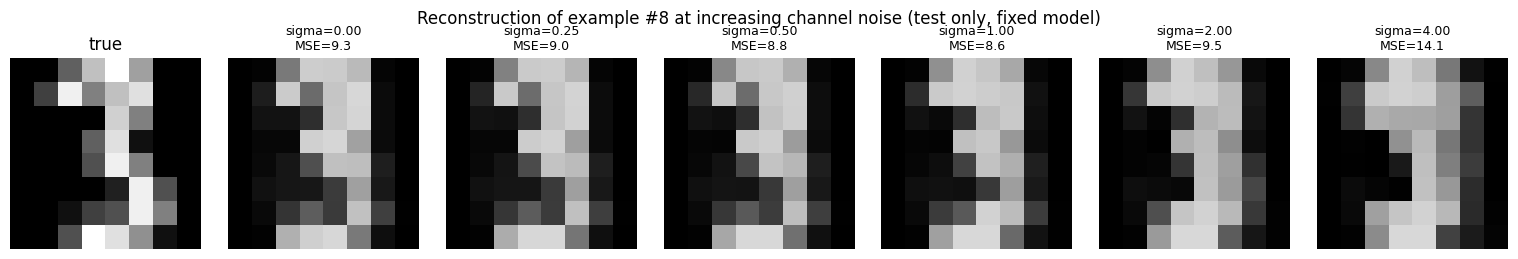

In [11]:
example_idx = 8 # the "0" used in section 6

sigmas_test = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0]
mses = []
recon_at_sigma = []
torch.manual_seed(0)  # so the noise draw is reproducible across runs
with torch.no_grad():
    for s in sigmas_test:
        x_time_s, _, xhat_time_s, _, _ = forward_pass(Xte, s)
        mse_s = torch.mean(((xhat_time_s - LATENCY_AE) - x_time_s) ** 2).item()
        mses.append(mse_s)
        recon_at_sigma.append((xhat_time_s[example_idx] - LATENCY_AE).clamp(0, T_MAX))
        print(f"channel sigma = {s:.2f}  ->  test MSE = {mse_s:.3f}")

# overall MSE curve (whole test set)
plt.figure(figsize=(6, 4))
plt.plot(sigmas_test, mses, marker="o")
plt.axhline(baseline_mse, color="gray", linestyle="--", label="baseline (mean image)")
plt.xlabel("channel noise standard deviation (sigma)")
plt.ylabel("spike-time MSE (test)")
plt.title("Robustness to channel noise (model trained with sigma=0.5)")
plt.legend()
plt.tight_layout()
plt.show()

# gallery: ONE example, reconstructed at increasing channel noise
true_img = x_time[example_idx].clamp(0, T_MAX).view(8, 8).numpy()
fig, axes = plt.subplots(1, len(sigmas_test) + 1, figsize=(2.2 * (len(sigmas_test) + 1), 2.6))
axes[0].imshow(16 - true_img, cmap="gray", vmin=0, vmax=16)
axes[0].set_title("true")
axes[0].axis("off")
for i, (s, recon) in enumerate(zip(sigmas_test, recon_at_sigma)):
    img = recon.view(8, 8).numpy()
    axes[i + 1].imshow(16 - img, cmap="gray", vmin=0, vmax=16)
    axes[i + 1].set_title(f"sigma={s:.2f}\nMSE={mses[i]:.1f}", fontsize=9)
    axes[i + 1].axis("off")
plt.suptitle(f"Reconstruction of example #{example_idx} at increasing channel noise (test only, fixed model)")
plt.tight_layout()
plt.show()

## Summary

- The exact-gradient simulator (Lambert W, alpha function) does solve the bottleneck
  collapse problem observed with the discretized snnTorch + surrogate gradient
  simulation: the decompressor now reconstructs content specific to each
  example (see the diagnostics in section 4), and beats the trivial baseline.
- The communication channel (Gaussian jitter on the bottleneck's spike times) is properly
  trained in the loop (gradients pass through it), and the learned code remains
  usable even at a noise level different from the one seen during training.
- Directions for improvement if you want to push further: a more systematic
  hyperparameter search (the values used here come from ONE row of the official table,
  for `n_hidden=8` -- the repo proposes others for K=16, K=32, and for different
  `noise_factor_ae` noise levels), moving to full MNIST (784 pixels), and
  replacing the Gaussian-jitter channel with the actual queuing channel
  (Lindley recursion) discussed earlier in the conversation, which accounts for the
  causal ordering of spikes.

We now move on to rate coding

In [12]:
import sys
sys.path.append(".")  # folder where rate_snn.py lives

from rate_snn import (
    rate_encode, decode_rate, van_rossum_distance,
    SNNLayer,SNNStack, delay_channel,
)
from snntorch import surrogate
from sklearn.datasets import load_digits
digits = load_digits()
X_all = torch.tensor(digits.data, dtype=torch.float32)  # (n, 64), values 0..16

n = X_all.shape[0]
perm = torch.randperm(n)
X_train = X_all[perm[: int(0.8 * n)]]
X_test = X_all[perm[int(0.8 * n) :]]
print(X_train.shape, X_test.shape)

torch.Size([1437, 64]) torch.Size([360, 64])


In [13]:
## A channel that can both drop and shift n spikes
def erasure_shift_channel(spikes, p_delete=0.1, p_shift=0.1, max_shift=2, rng=None):
    """
    Probabilistic channel applied INDEPENDENTLY to each neuron (unlike
    bulk_queue_delay_channel, which shares a single link across the N
    neurons). For each individual spike, independently:
      - drop with probability p_delete       (loss -- an erasure-channel type)
      - shift by +1..+max_shift steps with probability p_shift (random delay;
        lost if it falls outside the T window)
      - leave unchanged otherwise (remaining probability 1 - p_delete - p_shift)
    """
    assert p_delete + p_shift <= 1.0
    if rng is None:
        rng = np.random.default_rng()
    spikes_np = spikes.detach().cpu().numpy()
    batch, T, N = spikes_np.shape
    out = np.zeros_like(spikes_np)

    is_spike = spikes_np > 0.5
    r = rng.random(spikes_np.shape)

    # spikes kept as-is
    keep_mask = is_spike & (r >= p_delete + p_shift)
    out[keep_mask] = 1.0

    # shifted spikes
    shift_mask = is_spike & (r >= p_delete) & (r < p_delete + p_shift)
    shift_amounts = rng.integers(1, max_shift + 1, size=spikes_np.shape)
    b_idx, t_idx, n_idx = np.nonzero(shift_mask)
    new_t = t_idx + shift_amounts[b_idx, t_idx, n_idx]
    valid = new_t < T
    out[b_idx[valid], new_t[valid], n_idx[valid]] = 1.0
    # (dropped spikes -- r < p_delete -- are simply never written)

    return torch.tensor(out, dtype=spikes.dtype, device=spikes.device)


def erasure_shift_channel_ste(spikes, p_delete=0.1, p_shift=0.1, max_shift=2):
    """Trainable (straight-through) version of the channel above."""
    corrupted = erasure_shift_channel(spikes, p_delete=p_delete, p_shift=p_shift, max_shift=max_shift)
    return spikes + (corrupted - spikes).detach()

In [14]:
D_IN = 64        # pixels
T = 20           # rate-coding window's time steps
K_BOTTLENECK = 32  # bottleneck neurons (same size as the TTFS version)
P_MAX = 0.8       # max spike rate (pixel = 16 -> p = P_MAX)
CAPACITY = 4      # channel rate (spikes/time step, shared across the 8 neurons)
LR = 1e-2
N_EPOCHS = 200
spike_grad = surrogate.fast_sigmoid(slope=25)
compressor = SNNStack([64, 32, 16], beta=0.9, threshold=1.0,spike_grad=spike_grad)
decompressor = SNNStack([16, 32, 64], beta=0.9, threshold=1.0,spike_grad=spike_grad)

params = list(compressor.parameters()) + list(decompressor.parameters())
optimizer = torch.optim.Adam(params, lr=LR)

def forward_pass(pixels, capacity=CAPACITY, T=T):
    x = rate_encode(pixels, T=T, p_max=P_MAX)
    z = compressor(x)                              # (batch, T, 16) now
    #z_tilde = delay_channel(z, capacity=capacity)
    z_tilde = erasure_shift_channel_ste(z, p_delete=0.1, p_shift=0.1, max_shift=2)
    x_hat_spikes = decompressor(z_tilde)
    x_hat = decode_rate(x_hat_spikes, p_max=P_MAX)
    return x, x_hat_spikes, x_hat, z

epoch   0  train van-Rossum loss = 3.1606


epoch  10  train van-Rossum loss = 1.4961


epoch  20  train van-Rossum loss = 1.3461


epoch  30  train van-Rossum loss = 1.3141


epoch  40  train van-Rossum loss = 1.2698


...

epoch 160  train van-Rossum loss = 0.8784


epoch 170  train van-Rossum loss = 0.8574


epoch 180  train van-Rossum loss = 0.8418


epoch 190  train van-Rossum loss = 0.8274


epoch 199  train van-Rossum loss = 0.8115


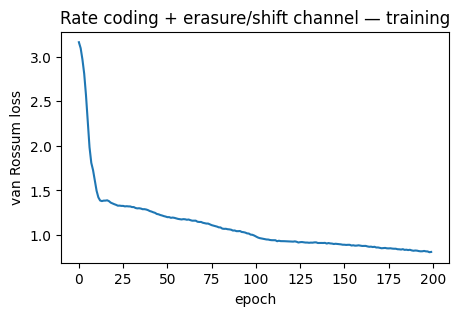

In [15]:
train_losses = []
for epoch in range(N_EPOCHS):
    compressor.train(); decompressor.train()
    x, x_hat_spikes, x_hat, z = forward_pass(X_train, capacity=CAPACITY)
    loss = van_rossum_distance(x, x_hat_spikes, tau=5.0)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(
        list(compressor.parameters()) + list(decompressor.parameters()), max_norm=5.0
    )
    optimizer.step()
    train_losses.append(loss.item())

    if epoch % 10 == 0 or epoch == N_EPOCHS - 1:
        print(f"epoch {epoch:3d}  train van-Rossum loss = {loss.item():.4f}")

plt.figure(figsize=(5, 3))
plt.plot(train_losses)
plt.xlabel("epoch"); plt.ylabel("van Rossum loss")
plt.title("Rate coding + erasure/shift channel — training")
plt.show()

In [16]:
compressor.eval(); decompressor.eval()
with torch.no_grad():
    x, x_hat_spikes, x_hat, z = forward_pass(X_test)  # note: forward_pass currently hardcodes p_delete=p_shift=0.1, max_shift=2 (see cell above); this call used to pass them explicitly under an older signature
mse_model = torch.mean((x_hat - X_test) ** 2).item()
mean_image = X_train.mean(dim=0, keepdim=True)
mse_baseline = torch.mean((mean_image - X_test) ** 2).item()

var_ratio = x_hat.var(dim=0).mean().item() / X_test.var(dim=0).mean().item()

resid_true = X_test - mean_image
resid_pred = x_hat - mean_image
corr = torch.corrcoef(torch.stack([resid_true.flatten(), resid_pred.flatten()]))[0, 1].item()

print(f"model MSE      : {mse_model:.3f}")
print(f"baseline MSE   : {mse_baseline:.3f}  (always predict the mean image)")
print(f"variance ratio : {var_ratio:.3f}   (close to 0 = collapse, close to 1 = good)")
print(f"residual correlation : {corr:.3f}")
print(f"mean spike rate of z : {z.mean().item():.3f}  (z-spikes/neuron/step)")

model MSE      : 9.326
baseline MSE   : 18.904  (always predict the mean image)
variance ratio : 0.541   (close to 0 = collapse, close to 1 = good)
residual correlation : 0.717
mean spike rate of z : 0.215  (z-spikes/neuron/step)


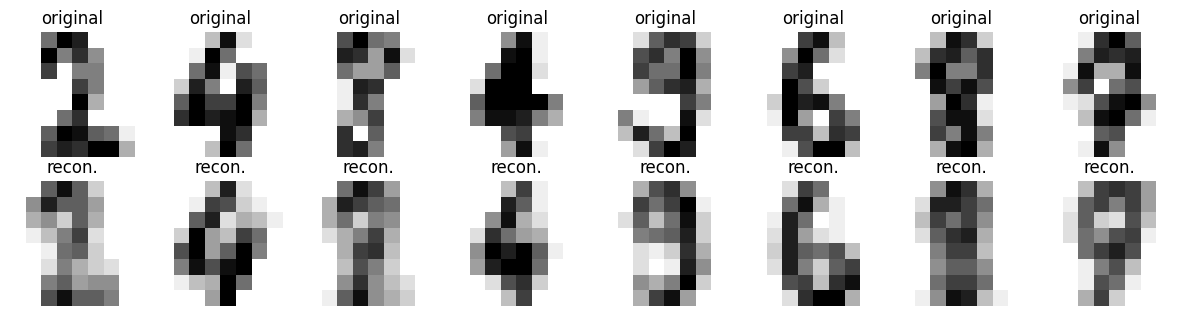

In [17]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i in range(8):
    axes[0, i].imshow(X_test[i].reshape(8, 8).numpy(), cmap="gray_r", vmin=0, vmax=16)
    axes[0, i].set_title("original"); axes[0, i].axis("off")
    axes[1, i].imshow(x_hat[i].reshape(8, 8).numpy(), cmap="gray_r", vmin=0, vmax=16)
    axes[1, i].set_title("recon."); axes[1, i].axis("off")
plt.tight_layout()
plt.show()

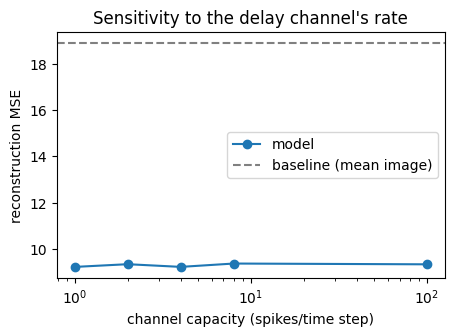

In [18]:
capacities = [1, 2, 4, 8, 100]  # 100 ≈ near-infinite channel (no real delay)
mses = []

with torch.no_grad():
    for cap in capacities:
        _, _, x_hat_c, _ = forward_pass(X_test, capacity=cap)
        mses.append(torch.mean((x_hat_c - X_test) ** 2).item())

plt.figure(figsize=(5, 3.2))
plt.plot(capacities, mses, "o-", label="model")
plt.axhline(mse_baseline, color="gray", linestyle="--", label="baseline (mean image)")
plt.xscale("log")
plt.xlabel("channel capacity (spikes/time step)")
plt.ylabel("reconstruction MSE")
plt.title("Sensitivity to the delay channel's rate")
plt.legend()
plt.show()

In [19]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from snntorch import surrogate

from rate_snn import (
    rate_encode, decode_rate, van_rossum_distance,
    SNNLayer
)


# ---------------------------------------------------------------------
# SNNStack: stacking several SNNLayer (defined here so the cell is
# self-contained, even if you've already added it to rate_snn.py)
# ---------------------------------------------------------------------
import torch.nn as nn

class SNNStack(nn.Module):
    def __init__(self, layer_sizes, beta=0.9, threshold=1.0, spike_grad=None):
        super().__init__()
        assert len(layer_sizes) >= 2
        self.layers = nn.ModuleList([
            SNNLayer(layer_sizes[i], layer_sizes[i + 1], beta=beta,
                     threshold=threshold, spike_grad=spike_grad)
            for i in range(len(layer_sizes) - 1)
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


def get_layers(model):
    return list(model.layers) if hasattr(model, "layers") else [model]


# ---------------------------------------------------------------------
# Data
# ---------------------------------------------------------------------
digits = load_digits()
X_all = torch.tensor(digits.data, dtype=torch.float32)
n = X_all.shape[0]
torch.manual_seed(0)
perm = torch.randperm(n)
X_train = X_all[perm[: int(0.8 * n)]]
X_test = X_all[perm[int(0.8 * n):]]

# ---------------------------------------------------------------------
# Shared hyperparameters
# ---------------------------------------------------------------------
D_IN = 64
T = 20
K_BOTTLENECK = 16     # same bottleneck size for BOTH models: only
                      # the depth differs, a fair comparison
P_MAX = 0.8
P_DELETE = 0.1
P_SHIFT = 0.1
MAX_SHIFT = 2
LR = 1e-2
N_EPOCHS = 300
CLIP_NORM = 5.0

spike_grad = surrogate.fast_sigmoid(slope=25)


def make_forward_pass(compressor, decompressor):
    def forward_pass(pixels):
        x = rate_encode(pixels, T=T, p_max=P_MAX)
        z = compressor(x)
        z_tilde = erasure_shift_channel_ste(z, p_delete=P_DELETE, p_shift=P_SHIFT, max_shift=MAX_SHIFT)
        x_hat_spikes = decompressor(z_tilde)
        x_hat = decode_rate(x_hat_spikes, p_max=P_MAX)
        return x, x_hat_spikes, x_hat, z
    return forward_pass


def train_model(compressor, decompressor, forward_pass, n_epochs=N_EPOCHS, lr=LR, label=""):
    optimizer = torch.optim.Adam(list(compressor.parameters()) + list(decompressor.parameters()), lr=lr)
    losses = []
    for epoch in range(n_epochs):
        compressor.train(); decompressor.train()
        x, x_hat_spikes, x_hat, z = forward_pass(X_train)
        loss = van_rossum_distance(x, x_hat_spikes, tau=5.0)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(compressor.parameters()) + list(decompressor.parameters()), max_norm=CLIP_NORM
        )
        optimizer.step()
        losses.append(loss.item())
        if epoch % 50 == 0 or epoch == n_epochs - 1:
            print(f"[{label}] epoch {epoch:3d}  loss = {loss.item():.4f}")
    return losses


# ---------------------------------------------------------------------
# Model A: direct input-output (no hidden layer)
# ---------------------------------------------------------------------
torch.manual_seed(1)
compressor_direct = SNNLayer(D_IN, K_BOTTLENECK, beta=0.9, threshold=1.0, spike_grad=spike_grad)
decompressor_direct = SNNLayer(K_BOTTLENECK, D_IN, beta=0.9, threshold=1.0, spike_grad=spike_grad)
forward_pass_direct = make_forward_pass(compressor_direct, decompressor_direct)

print("=== Training the DIRECT model (64 -> 16 -> 64) ===")
losses_direct = train_model(compressor_direct, decompressor_direct, forward_pass_direct, label="direct")

# ---------------------------------------------------------------------
# Model B: with a hidden layer
# ---------------------------------------------------------------------
torch.manual_seed(1)
compressor_hidden = SNNStack([D_IN, 32, K_BOTTLENECK], beta=0.9, threshold=1.0, spike_grad=spike_grad)
decompressor_hidden = SNNStack([K_BOTTLENECK, 32, D_IN], beta=0.9, threshold=1.0, spike_grad=spike_grad)
forward_pass_hidden = make_forward_pass(compressor_hidden, decompressor_hidden)

print("\n=== Training the HIDDEN model (64 -> 32 -> 16 -> 32 -> 64) ===")
losses_hidden = train_model(compressor_hidden, decompressor_hidden, forward_pass_hidden, label="hidden")

=== Training the DIRECT model (64 -> 16 -> 64) ===
[direct] epoch   0  loss = 2.9911


[direct] epoch  50  loss = 0.8545


[direct] epoch 100  loss = 0.6923


[direct] epoch 150  loss = 0.6325


[direct] epoch 200  loss = 0.5838


...

[hidden] epoch 100  loss = 1.1339


[hidden] epoch 150  loss = 0.9891


[hidden] epoch 200  loss = 0.8890


[hidden] epoch 250  loss = 0.8567


[hidden] epoch 299  loss = 0.8266


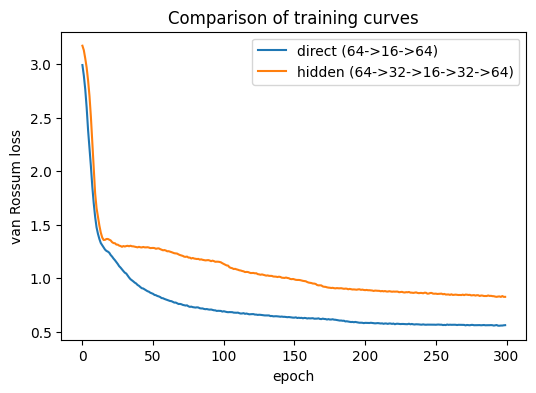

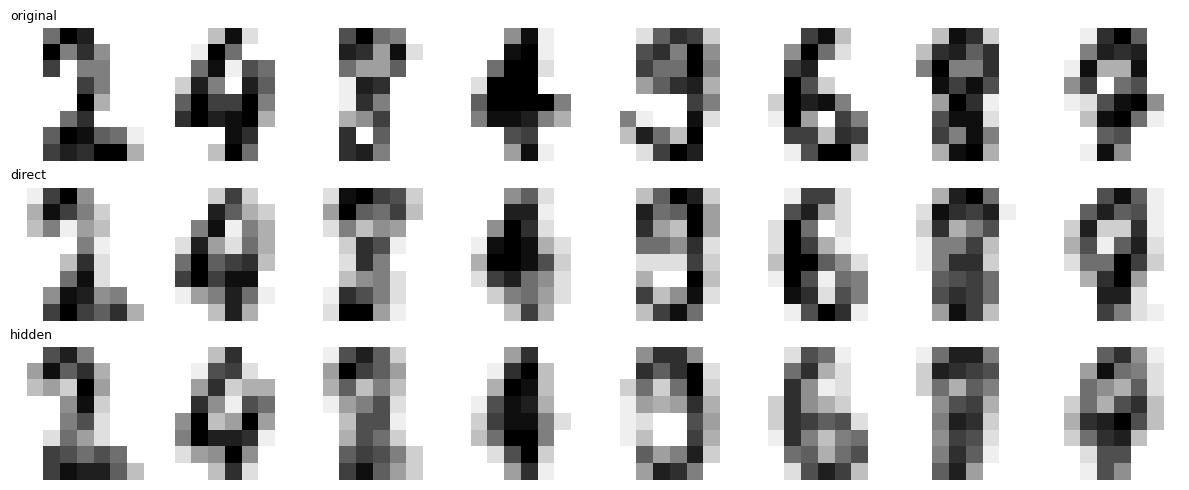

In [20]:
# ---- loss curves ----
plt.figure(figsize=(6, 4))
plt.plot(losses_direct, label="direct (64->16->64)")
plt.plot(losses_hidden, label="hidden (64->32->16->32->64)")
plt.xlabel("epoch"); plt.ylabel("van Rossum loss")
plt.title("Comparison of training curves")
plt.legend()
plt.show()

# ---- visual reconstructions, same test examples for both ----
compressor_direct.eval(); decompressor_direct.eval()
compressor_hidden.eval(); decompressor_hidden.eval()

N_SHOW = 8
X_show = X_test[:N_SHOW]

with torch.no_grad():
    _, _, x_hat_direct, _ = forward_pass_direct(X_show)
    _, _, x_hat_hidden, _ = forward_pass_hidden(X_show)

fig, axes = plt.subplots(3, N_SHOW, figsize=(1.5 * N_SHOW, 5))
for i in range(N_SHOW):
    axes[0, i].imshow(X_show[i].reshape(8, 8).numpy(), cmap="gray_r", vmin=0, vmax=16)
    axes[0, i].axis("off")
    axes[1, i].imshow(x_hat_direct[i].reshape(8, 8).numpy(), cmap="gray_r", vmin=0, vmax=16)
    axes[1, i].axis("off")
    axes[2, i].imshow(x_hat_hidden[i].reshape(8, 8).numpy(), cmap="gray_r", vmin=0, vmax=16)
    axes[2, i].axis("off")
axes[0, 0].set_title("original", loc="left", fontsize=9)
axes[1, 0].set_title("direct", loc="left", fontsize=9)
axes[2, 0].set_title("hidden", loc="left", fontsize=9)
plt.tight_layout()
plt.show()

In [21]:
import copy

RUN_OVERFIT_TEST = True
RUN_MULTISEED_TEST = True
N_SEEDS = 2
N_EPOCHS_QUICK = 80


def run_sanity_checks(compressor, decompressor, forward_pass, layer_sizes_comp, layer_sizes_decomp, label):
    print("#" * 70)
    print(f"# SANITY CHECKS -- model: {label}")
    print("#" * 70)
    compressor.eval(); decompressor.eval()

    print("1) Encoding noise floor (no network)")
    with torch.no_grad():
        x_direct = rate_encode(X_test, T=T, p_max=P_MAX)
        x_hat_direct = decode_rate(x_direct, p_max=P_MAX)
        mse_floor = torch.mean((x_hat_direct - X_test) ** 2).item()
    print(f"   MSE floor = {mse_floor:.3f}\n")

    print("2) Spike fractions per layer")
    with torch.no_grad():
        x = rate_encode(X_test, T=T, p_max=P_MAX)
        print("   Compressor:")
        for i, layer in enumerate(get_layers(compressor)):
            x = layer(x)
            r = x.mean().item()
            print(f"     layer {i}: {r:.3f}" + ("  <-- SUSPECT" if r < 0.02 or r > 0.95 else ""))
        z_test = x
        z_tilde_test = erasure_shift_channel_ste(z_test, p_delete=P_DELETE, p_shift=P_SHIFT, max_shift=MAX_SHIFT)
        xd = z_tilde_test
        print("   Decompressor:")
        for i, layer in enumerate(get_layers(decompressor)):
            xd = layer(xd)
            r = xd.mean().item()
            print(f"     layer {i}: {r:.3f}" + ("  <-- SUSPECT" if r < 0.02 or r > 0.95 else ""))
    print()

    print("3) Baselines")
    with torch.no_grad():
        x, x_hat_spikes, x_hat, z = forward_pass(X_test)
    mse_model = torch.mean((x_hat - X_test) ** 2).item()
    mean_image = X_train.mean(dim=0, keepdim=True)
    mse_baseline = torch.mean((mean_image - X_test) ** 2).item()
    ok_baseline = mse_model < mse_baseline
    print(f"   model MSE = {mse_model:.3f} | baseline = {mse_baseline:.3f} | floor = {mse_floor:.3f}")
    print(f"   beats the baseline? {'YES' if ok_baseline else 'NO -- SUSPECT'}\n")

    print("4) Variance ratio / residual correlation")
    var_ratio = x_hat.var(dim=0).mean().item() / X_test.var(dim=0).mean().item()
    resid_true = X_test - mean_image
    resid_pred = x_hat - mean_image
    corr = torch.corrcoef(torch.stack([resid_true.flatten(), resid_pred.flatten()]))[0, 1].item()
    print(f"   var-ratio = {var_ratio:.3f} | correlation = {corr:.3f}\n")

    print("5) Gradient norms per layer")
    compressor.train(); decompressor.train()
    compressor.zero_grad(); decompressor.zero_grad()
    x, x_hat_spikes, x_hat, z = forward_pass(X_train)
    loss_probe = van_rossum_distance(x, x_hat_spikes, tau=5.0)
    loss_probe.backward()
    grad_norms = {}
    for name, p in list(compressor.named_parameters()) + list(decompressor.named_parameters()):
        if p.grad is not None:
            g = p.grad.norm().item()
            grad_norms[name] = g
            print(f"   {name:20s} {g:.5f}" + ("  <-- SUSPECT" if g < 1e-6 or g > 50 else ""))
    ratio_extreme = max(grad_norms.values()) / max(min(grad_norms.values()), 1e-12)
    print(f"   max/min ratio = {ratio_extreme:.1f}x")
    compressor.zero_grad(); decompressor.zero_grad()
    print()

    print("6) Channel ablation")
    compressor.eval(); decompressor.eval()
    with torch.no_grad():
        x_e = rate_encode(X_test, T=T, p_max=P_MAX)
        z_e = compressor(x_e)
        z_curr = erasure_shift_channel_ste(z_e, p_delete=P_DELETE, p_shift=P_SHIFT, max_shift=MAX_SHIFT)
        z_none = erasure_shift_channel_ste(z_e, p_delete=0.0, p_shift=0.0, max_shift=MAX_SHIFT)
        xh_curr = decode_rate(decompressor(z_curr), p_max=P_MAX)
        xh_none = decode_rate(decompressor(z_none), p_max=P_MAX)
    mse_curr = torch.mean((xh_curr - X_test) ** 2).item()
    mse_none = torch.mean((xh_none - X_test) ** 2).item()
    print(f"   current-channel MSE = {mse_curr:.3f} | transparent-channel MSE = {mse_none:.3f}")
    print("   -> negligible channel" if abs(mse_curr - mse_none) < 0.05 * mse_none else "   -> the channel has a measurable effect")
    print()

    if RUN_OVERFIT_TEST:
        print("7) Mini-batch overfit (fixed target + van Rossum floor)")
        comp_tmp = copy.deepcopy(compressor)
        decomp_tmp = copy.deepcopy(decompressor)
        opt_tmp = torch.optim.Adam(list(comp_tmp.parameters()) + list(decomp_tmp.parameters()), lr=1e-2)
        X_tiny = X_train[:8]
        xx_fixed = rate_encode(X_tiny, T=T, p_max=P_MAX)
        xx_fixed2 = rate_encode(X_tiny, T=T, p_max=P_MAX)
        vr_floor = van_rossum_distance(xx_fixed, xx_fixed2, tau=5.0).item()
        losses_tmp = []
        for ep in range(600):
            comp_tmp.train(); decomp_tmp.train()
            zz = comp_tmp(xx_fixed)
            zzt = erasure_shift_channel_ste(zz, p_delete=P_DELETE, p_shift=P_SHIFT, max_shift=MAX_SHIFT)
            xxh_spk = decomp_tmp(zzt)
            l = van_rossum_distance(xx_fixed, xxh_spk, tau=5.0)
            opt_tmp.zero_grad(); l.backward(); opt_tmp.step()
            losses_tmp.append(l.item())
        print(f"   van Rossum floor = {vr_floor:.4f} | final loss = {losses_tmp[-1]:.4f}")
        print("   -> OK, close to the floor" if losses_tmp[-1] < 1.5 * vr_floor else "   -> SUSPECT")
        del comp_tmp, decomp_tmp, opt_tmp
        print()

    if RUN_MULTISEED_TEST:
        print(f"8) Reproducibility ({N_SEEDS} seeds, {N_EPOCHS_QUICK} ep)")
        final_mses = []
        for seed in range(N_SEEDS):
            torch.manual_seed(100 + seed)
            comp_s = SNNStack(layer_sizes_comp, beta=0.9, threshold=1.0, spike_grad=spike_grad) if len(layer_sizes_comp) > 2 \
                     else SNNLayer(layer_sizes_comp[0], layer_sizes_comp[-1], beta=0.9, threshold=1.0, spike_grad=spike_grad)
            decomp_s = SNNStack(layer_sizes_decomp, beta=0.9, threshold=1.0, spike_grad=spike_grad) if len(layer_sizes_decomp) > 2 \
                       else SNNLayer(layer_sizes_decomp[0], layer_sizes_decomp[-1], beta=0.9, threshold=1.0, spike_grad=spike_grad)
            opt_s = torch.optim.Adam(list(comp_s.parameters()) + list(decomp_s.parameters()), lr=LR)
            fp_s = make_forward_pass(comp_s, decomp_s)
            for ep in range(N_EPOCHS_QUICK):
                comp_s.train(); decomp_s.train()
                x, x_hat_spikes, x_hat, z = fp_s(X_train)
                l = van_rossum_distance(x, x_hat_spikes, tau=5.0)
                opt_s.zero_grad(); l.backward(); opt_s.step()
            comp_s.eval(); decomp_s.eval()
            with torch.no_grad():
                _, _, xht, _ = fp_s(X_test)
            mse_seed = torch.mean((xht - X_test) ** 2).item()
            final_mses.append(mse_seed)
            print(f"   seed {seed}: MSE = {mse_seed:.3f}")
        spread = max(final_mses) - min(final_mses)
        print(f"   spread = {spread:.3f}")
        print("   -> stable" if spread <= 0.3 * min(final_mses) else "   -> SUSPECT, high variance")

    print()
    return dict(mse_model=mse_model, mse_baseline=mse_baseline, mse_floor=mse_floor,
                var_ratio=var_ratio, corr=corr, grad_ratio=ratio_extreme)


results_direct = run_sanity_checks(
    compressor_direct, decompressor_direct, forward_pass_direct,
    [D_IN, K_BOTTLENECK], [K_BOTTLENECK, D_IN], label="DIRECT (64->16->64)",
)
results_hidden = run_sanity_checks(
    compressor_hidden, decompressor_hidden, forward_pass_hidden,
    [D_IN, 32, K_BOTTLENECK], [K_BOTTLENECK, 32, D_IN], label="HIDDEN (64->32->16->32->64)",
)

print("=" * 70)
print("COMPARATIVE SUMMARY")
print("=" * 70)
print(f"{'':20s} {'direct':>12s} {'hidden':>12s}")
for key in ["mse_model", "var_ratio", "corr", "grad_ratio"]:
    print(f"{key:20s} {results_direct[key]:12.3f} {results_hidden[key]:12.3f}")

######################################################################
# SANITY CHECKS -- model: DIRECT (64->16->64)
######################################################################
1) Encoding noise floor (no network)
   MSE floor = 1.657

2) Spike fractions per layer
   Compressor:
     layer 0: 0.417
   Decompressor:
     layer 0: 0.236

3) Baselines


   model MSE = 5.654 | baseline = 18.904 | floor = 1.657
   beats the baseline? YES

4) Variance ratio / residual correlation
   var-ratio = 0.688 | correlation = 0.839

5) Gradient norms per layer
   fc.weight            0.00729
   fc.bias              0.00251
   fc.weight            0.01195
   fc.bias              0.00668
   max/min ratio = 1.8x

6) Channel ablation
   current-channel MSE = 5.604 | transparent-channel MSE = 5.319
   -> the channel has a measurable effect

7) Mini-batch overfit (fixed target + van Rossum floor)


   van Rossum floor = 0.5000 | final loss = 0.2345
   -> OK, close to the floor

8) Reproducibility (2 seeds, 80 ep)


   seed 0: MSE = 10.240


   seed 1: MSE = 8.526
   spread = 1.714
   -> stable

######################################################################
# SANITY CHECKS -- model: HIDDEN (64->32->16->32->64)
######################################################################
1) Encoding noise floor (no network)
   MSE floor = 1.607

2) Spike fractions per layer
   Compressor:
     layer 0: 0.498
     layer 1: 0.467
   Decompressor:
     layer 0: 0.093
     layer 1: 0.231

3) Baselines
   model MSE = 10.199 | baseline = 18.904 | floor = 1.607
   beats the baseline? YES

4) Variance ratio / residual correlation
   var-ratio = 0.485 | correlation = 0.682

5) Gradient norms per layer
   layers.0.fc.weight   0.00039
   layers.0.fc.bias     0.00014
   layers.1.fc.weight   0.00314
   layers.1.fc.bias     0.00082
   layers.0.fc.weight   0.00504
   layers.0.fc.bias     0.00239
   layers.1.fc.weight   0.02129
   layers.1.fc.bias     0.01590
   max/min ratio = 8.9x

6) Channel ablation
   current-channel MSE = 10.107 | t

   van Rossum floor = 0.4890 | final loss = 0.2301
   -> OK, close to the floor

8) Reproducibility (2 seeds, 80 ep)


   seed 0: MSE = 19.230


   seed 1: MSE = 11.218
   spread = 8.012
   -> SUSPECT, high variance

COMPARATIVE SUMMARY
                           direct       hidden
mse_model                   5.654       10.199
var_ratio                   0.688        0.485
corr                        0.839        0.682
grad_ratio                  1.788        8.899


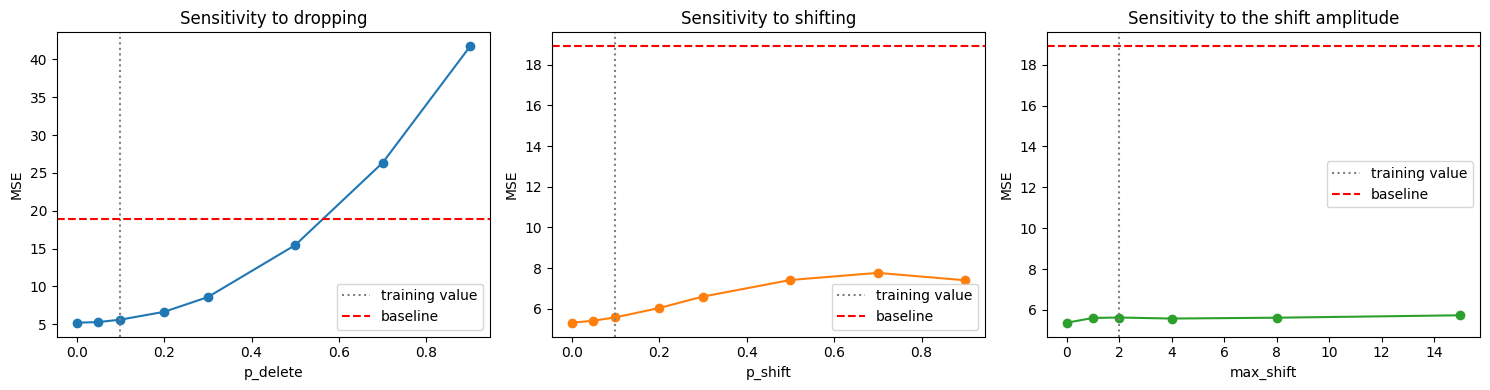

p_delete : [(0.0, 5.203), (0.05, 5.297), (0.1, 5.611), (0.2, 6.645), (0.3, 8.59), (0.5, 15.469), (0.7, 26.358), (0.9, 41.747)]
p_shift  : [(0.0, 5.319), (0.05, 5.42), (0.1, 5.583), (0.2, 6.041), (0.3, 6.604), (0.5, 7.418), (0.7, 7.768), (0.9, 7.405)]
max_shift: [(0, 5.371), (1, 5.607), (2, 5.627), (4, 5.578), (8, 5.618), (15, 5.737)]


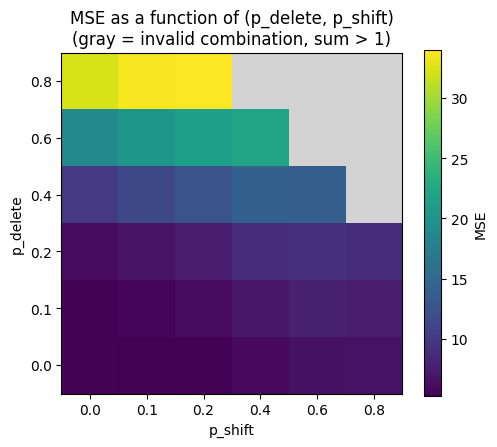

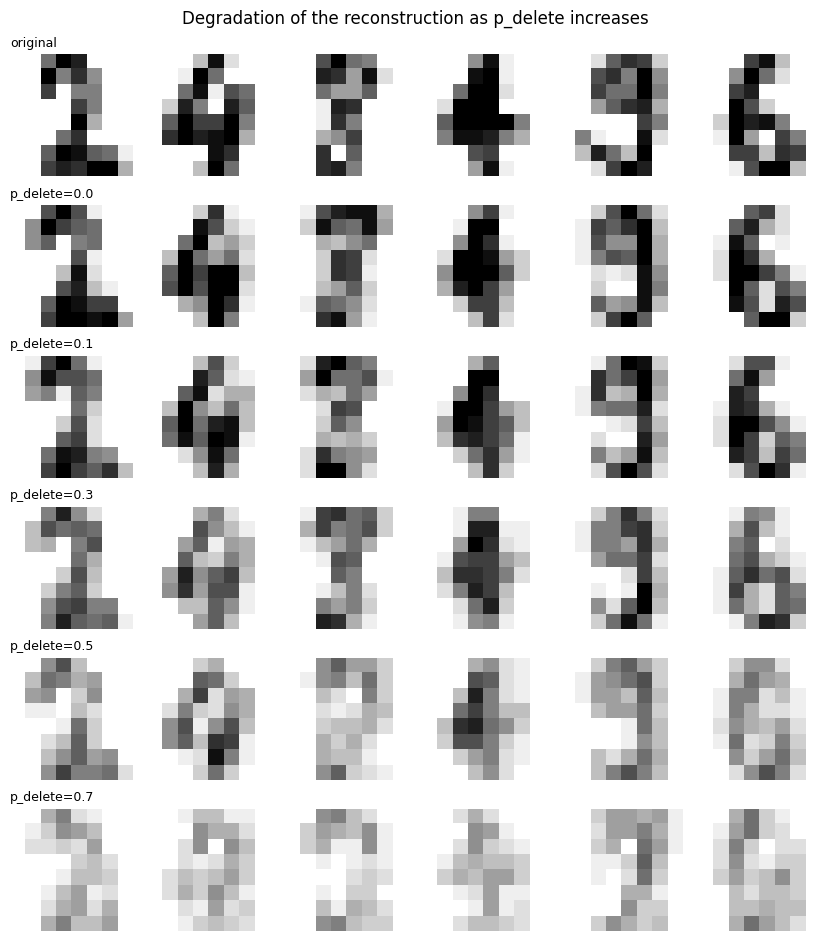

In [22]:
import numpy as np
import matplotlib.pyplot as plt

compressor_direct.eval(); decompressor_direct.eval()
mean_image = X_train.mean(dim=0, keepdim=True)
mse_baseline = torch.mean((mean_image - X_test) ** 2).item()

def erasure_shift_channel(spikes, p_delete=0.1, p_shift=0.1, max_shift=2, rng=None):
    assert p_delete + p_shift <= 1.0
    if rng is None:
        rng = np.random.default_rng()
    spikes_np = spikes.detach().cpu().numpy()
    batch, T, N = spikes_np.shape
    out = np.zeros_like(spikes_np)

    is_spike = spikes_np > 0.5
    r = rng.random(spikes_np.shape)

    if max_shift < 1:
        # no shift possible: spikes "to be shifted" simply stay in place
        keep_mask = is_spike & (r >= p_delete)
        out[keep_mask] = 1.0
        return torch.tensor(out, dtype=spikes.dtype, device=spikes.device)

    keep_mask = is_spike & (r >= p_delete + p_shift)
    out[keep_mask] = 1.0

    shift_mask = is_spike & (r >= p_delete) & (r < p_delete + p_shift)
    shift_amounts = rng.integers(1, max_shift + 1, size=spikes_np.shape)
    b_idx, t_idx, n_idx = np.nonzero(shift_mask)
    new_t = t_idx + shift_amounts[b_idx, t_idx, n_idx]
    valid = new_t < T
    out[b_idx[valid], new_t[valid], n_idx[valid]] = 1.0

    return torch.tensor(out, dtype=spikes.dtype, device=spikes.device)
def eval_channel(p_delete, p_shift, max_shift=MAX_SHIFT, pixels=X_test):
    with torch.no_grad():
        x = rate_encode(pixels, T=T, p_max=P_MAX)
        z = compressor_direct(x)
        z_tilde = erasure_shift_channel_ste(z, p_delete=p_delete, p_shift=p_shift, max_shift=max_shift)
        x_hat_spikes = decompressor_direct(z_tilde)
        x_hat = decode_rate(x_hat_spikes, p_max=P_MAX)
    mse = torch.mean((x_hat - pixels) ** 2).item()
    return mse, x_hat


# ---------------------------------------------------------------------
# 1) 1D sweeps: sensitivity to each channel parameter separately
# ---------------------------------------------------------------------
p_delete_values = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
mses_delete = [eval_channel(p, P_SHIFT)[0] for p in p_delete_values]

p_shift_values = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
mses_shift = [eval_channel(P_DELETE, p)[0] for p in p_shift_values]

max_shift_values = [0, 1, 2, 4, 8, 15]
mses_maxshift = [eval_channel(P_DELETE, P_SHIFT, max_shift=m)[0] for m in max_shift_values]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(p_delete_values, mses_delete, "o-")
axes[0].axvline(P_DELETE, color="gray", linestyle=":", label="training value")
axes[0].axhline(mse_baseline, color="red", linestyle="--", label="baseline")
axes[0].set_xlabel("p_delete"); axes[0].set_ylabel("MSE"); axes[0].set_title("Sensitivity to dropping")
axes[0].legend()

axes[1].plot(p_shift_values, mses_shift, "o-", color="tab:orange")
axes[1].axvline(P_SHIFT, color="gray", linestyle=":", label="training value")
axes[1].axhline(mse_baseline, color="red", linestyle="--", label="baseline")
axes[1].set_xlabel("p_shift"); axes[1].set_ylabel("MSE"); axes[1].set_title("Sensitivity to shifting")
axes[1].legend()

axes[2].plot(max_shift_values, mses_maxshift, "o-", color="tab:green")
axes[2].axvline(MAX_SHIFT, color="gray", linestyle=":", label="training value")
axes[2].axhline(mse_baseline, color="red", linestyle="--", label="baseline")
axes[2].set_xlabel("max_shift"); axes[2].set_ylabel("MSE"); axes[2].set_title("Sensitivity to the shift amplitude")
axes[2].legend()
plt.tight_layout()
plt.show()

print("p_delete :", list(zip(p_delete_values, [round(m, 3) for m in mses_delete])))
print("p_shift  :", list(zip(p_shift_values, [round(m, 3) for m in mses_shift])))
print("max_shift:", list(zip(max_shift_values, [round(m, 3) for m in mses_maxshift])))


# ---------------------------------------------------------------------
# 2) 2D map: p_delete x p_shift interaction
# ---------------------------------------------------------------------
grid_vals = [0.0, 0.1, 0.2, 0.4, 0.6, 0.8]
heat = np.full((len(grid_vals), len(grid_vals)), np.nan)
for i, pd in enumerate(grid_vals):
    for j, ps in enumerate(grid_vals):
        if pd + ps <= 1.0:
            heat[i, j] = eval_channel(pd, ps)[0]

heat_masked = np.ma.masked_invalid(heat)
cmap = plt.cm.viridis.copy()
cmap.set_bad(color="lightgray")  # invalid combinations (sum > 1) in gray

plt.figure(figsize=(5.5, 4.5))
im = plt.imshow(heat_masked, origin="lower", cmap=cmap)
plt.xticks(range(len(grid_vals)), grid_vals); plt.yticks(range(len(grid_vals)), grid_vals)
plt.xlabel("p_shift"); plt.ylabel("p_delete")
plt.title("MSE as a function of (p_delete, p_shift)\n(gray = invalid combination, sum > 1)")
plt.colorbar(im, label="MSE")
plt.show()


# ---------------------------------------------------------------------
# 3) Visual gallery: progressive degradation (increasing p_delete)
# ---------------------------------------------------------------------
severities = [0.0, 0.1, 0.3, 0.5, 0.7]
N_SHOW = 6
X_show = X_test[:N_SHOW]

fig, axes = plt.subplots(len(severities) + 1, N_SHOW, figsize=(1.4 * N_SHOW, 1.6 * (len(severities) + 1)))
for i in range(N_SHOW):
    axes[0, i].imshow(X_show[i].reshape(8, 8).numpy(), cmap="gray_r", vmin=0, vmax=16)
    axes[0, i].axis("off")
axes[0, 0].set_title("original", loc="left", fontsize=9)

for row, p_del in enumerate(severities, start=1):
    _, x_hat_sev = eval_channel(p_del, P_SHIFT, pixels=X_show)
    for i in range(N_SHOW):
        axes[row, i].imshow(x_hat_sev[i].reshape(8, 8).numpy(), cmap="gray_r", vmin=0, vmax=16)
        axes[row, i].axis("off")
    axes[row, 0].set_title(f"p_delete={p_del}", loc="left", fontsize=9)

plt.suptitle("Degradation of the reconstruction as p_delete increases")
plt.tight_layout()
plt.show()

p_delete_train=0.0 -> MSE=4.196, var-ratio=0.761


p_delete_train=0.1 -> MSE=4.716, var-ratio=0.747


p_delete_train=0.3 -> MSE=6.125, var-ratio=0.664


p_delete_train=0.5 -> MSE=7.916, var-ratio=0.551


p_delete_train=0.7 -> MSE=11.185, var-ratio=0.392


p_delete_train=0.9 -> MSE=15.311, var-ratio=0.165


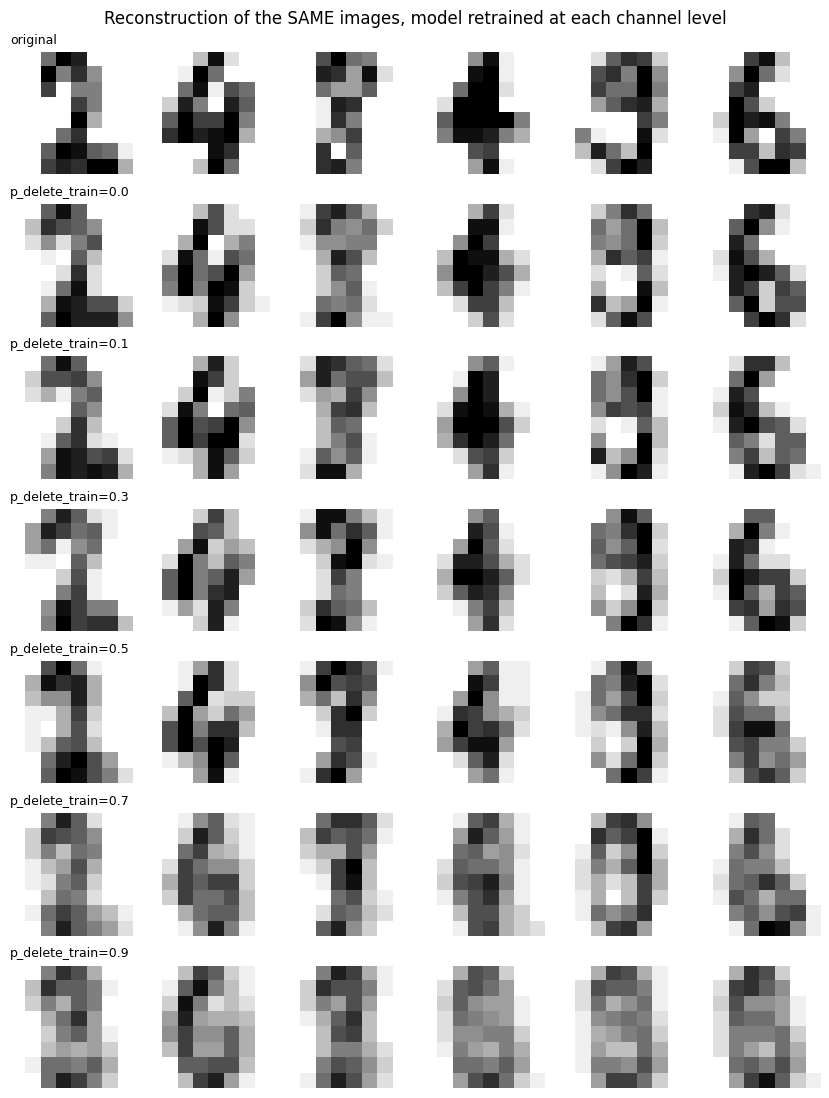

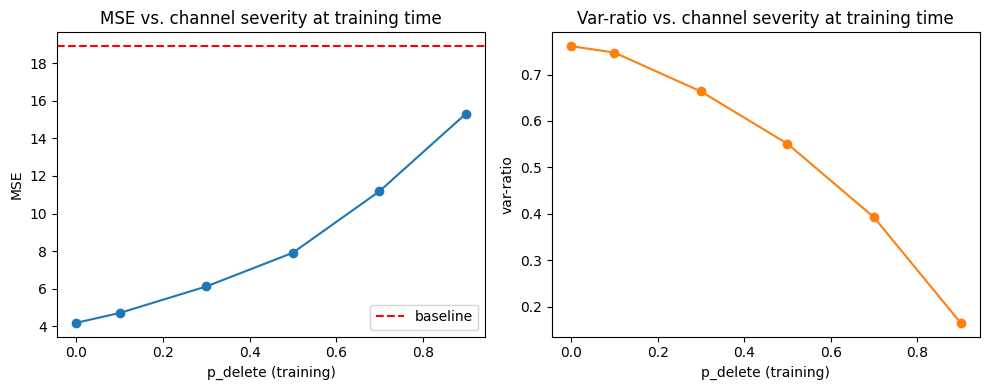

In [23]:
p_del_train_values = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9]
N_SHOW = 6
X_show = X_test[:N_SHOW]

results_curriculum = []
recon_by_level = []

for p_del_train in p_del_train_values:
    torch.manual_seed(42)
    comp_t = SNNLayer(D_IN, K_BOTTLENECK, beta=0.9, threshold=1.0, spike_grad=spike_grad)
    decomp_t = SNNLayer(K_BOTTLENECK, D_IN, beta=0.9, threshold=1.0, spike_grad=spike_grad)
    opt_t = torch.optim.Adam(list(comp_t.parameters()) + list(decomp_t.parameters()), lr=LR)

    for ep in range(N_EPOCHS):
        comp_t.train(); decomp_t.train()
        x = rate_encode(X_train, T=T, p_max=P_MAX)
        z = comp_t(x)
        z_tilde = erasure_shift_channel_ste(z, p_delete=p_del_train, p_shift=P_SHIFT, max_shift=MAX_SHIFT)
        x_hat_spk = decomp_t(z_tilde)
        loss = van_rossum_distance(x, x_hat_spk, tau=5.0)
        opt_t.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(list(comp_t.parameters()) + list(decomp_t.parameters()), max_norm=5.0)
        opt_t.step()

    comp_t.eval(); decomp_t.eval()
    with torch.no_grad():
        # metrics on the whole test set
        xt = rate_encode(X_test, T=T, p_max=P_MAX)
        zt = comp_t(xt)
        ztt = erasure_shift_channel_ste(zt, p_delete=p_del_train, p_shift=P_SHIFT, max_shift=MAX_SHIFT)
        xht = decode_rate(decomp_t(ztt), p_max=P_MAX)
        mse_t = torch.mean((xht - X_test) ** 2).item()
        var_ratio_t = xht.var(dim=0).mean().item() / X_test.var(dim=0).mean().item()

        # reconstruction of the SAME images for the visual gallery
        x_show_enc = rate_encode(X_show, T=T, p_max=P_MAX)
        z_show = comp_t(x_show_enc)
        z_show_tilde = erasure_shift_channel_ste(z_show, p_delete=p_del_train, p_shift=P_SHIFT, max_shift=MAX_SHIFT)
        x_hat_show = decode_rate(decomp_t(z_show_tilde), p_max=P_MAX)

    results_curriculum.append((p_del_train, mse_t, var_ratio_t))
    recon_by_level.append(x_hat_show)
    print(f"p_delete_train={p_del_train:.1f} -> MSE={mse_t:.3f}, var-ratio={var_ratio_t:.3f}")

# ---------------------------------------------------------------------
# Visual gallery: same images, one row per channel level
# ---------------------------------------------------------------------
fig, axes = plt.subplots(len(p_del_train_values) + 1, N_SHOW,
                          figsize=(1.4 * N_SHOW, 1.6 * (len(p_del_train_values) + 1)))

for i in range(N_SHOW):
    axes[0, i].imshow(X_show[i].reshape(8, 8).numpy(), cmap="gray_r", vmin=0, vmax=16)
    axes[0, i].axis("off")
axes[0, 0].set_title("original", loc="left", fontsize=9)

for row, (p_del, x_hat_lvl) in enumerate(zip(p_del_train_values, recon_by_level), start=1):
    for i in range(N_SHOW):
        axes[row, i].imshow(x_hat_lvl[i].reshape(8, 8).numpy(), cmap="gray_r", vmin=0, vmax=16)
        axes[row, i].axis("off")
    axes[row, 0].set_title(f"p_delete_train={p_del}", loc="left", fontsize=9)

plt.suptitle("Reconstruction of the SAME images, model retrained at each channel level")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Summary curve
# ---------------------------------------------------------------------
p_vals = [r[0] for r in results_curriculum]
mse_vals = [r[1] for r in results_curriculum]
var_vals = [r[2] for r in results_curriculum]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(p_vals, mse_vals, "o-")
axes[0].axhline(mse_baseline, color="red", linestyle="--", label="baseline")
axes[0].set_xlabel("p_delete (training)"); axes[0].set_ylabel("MSE"); axes[0].legend()
axes[0].set_title("MSE vs. channel severity at training time")

axes[1].plot(p_vals, var_vals, "o-", color="tab:orange")
axes[1].set_xlabel("p_delete (training)"); axes[1].set_ylabel("var-ratio")
axes[1].set_title("Var-ratio vs. channel severity at training time")
plt.tight_layout()
plt.show()